# Friday-17th (*Venerdì 17*) — a quantitative teardown 🔬
### One-sample *t* across independent events · a Welch contrast vs other Fridays · a Wilson down-day rate · a multi-seed random-calendar placebo · a look-elsewhere Bonferroni sweep · a costed short · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Unlucky_day%3F: Busted](https://img.shields.io/badge/Unlucky_day%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **Italy's FTSE MIB trades weak on Friday the 17th** — is folk superstition (*eptacaidecafobia*), the Latin cousin of the Friday-13th trade. Its only academic neighbour is Kolb & Rodriguez (1987) on the 1940s–80s Dow, a result no modern tape reproduces. The job here is to measure the *Italian 17th* honestly, on the *Italian tape*, with the right inference unit for a ~1.7-per-year calendar event.

> ⚠️ **Data note.** Primary tape: **`FTSEMIB.MI`** (FTSE MIB, EUR, **price-only** index), yfinance daily closes 1998-01-02→2026-06-30. Vehicle: **`EWI`** (iShares MSCI Italy, USD, **total-return**), 1996→2026. Venerdì-17 dates are pure calendar arithmetic — **known before the open, zero look-ahead**. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `e5483c326431`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from friday_17th import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    MIB = st.build_frame(PRICES[data.MIB])
    EWI = st.build_frame(PRICES[data.EWI])
else:
    PRICES = MIB = EWI = None
print("real cache present:", HAVE_REAL,
      "| Venerdi 17 events -> MIB:", (0 if MIB is None else int(MIB['is_f17'].sum())),
      "EWI:", (0 if EWI is None else int(EWI['is_f17'].sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'fp': 'e5483c326431', 'mib_rows': 7276, 'ewi_rows': 7619, 'mib_lo': '1998-01-02', 'mib_hi': '2026-06-30', 'ewi_lo': '1996-03-19', 'ewi_hi': '2026-06-30', 'm_n': 49, 'm_mean': 26.285, 'm_t': 1.267, 'm_other_mean': -2.651, 'm_contrast': 28.936, 'm_welch_t': 1.371, 'm_welch_p': 0.1703, 'm_all_mean': 0.86, 'm_contrast_all': 25.425, 'm_welch_p_all': 0.2219, 'm_down_k': 23, 'm_down_n': 49, 'm_down_rate': 46.9, 'm_down_lo': 33.7, 'm_down_hi': 60.6, 'm_pl_obs': 26.285, 'm_pl_null': -2.811, 'm_pl_sd': 20.601, 'm_pl_p': 0.9266, 'm_pl_draws': 10000, 'm_sh_n': 49, 'm_sh_gross': -26.285, 'm_sh_gross_t': -1.27, 'm_sh_net': -38.285, 'm_sh_net_t': -1.85, 'm_sh_win': 42.9, 'm_sh_be': 12.0, 'm_sweep': {10: [47, -62.42, -62.798, 0.01296, 0.0648], 3: [47, 36.755, 39.717, 0.04728, 0.23639], 17: [49, 26.285, 28.936, 0.1703, 0.85147], 24: [47, -44.615, -44.393, 0.21847, 1.0], 31: [26, 4.781, 6.568, 0.78178, 1.0]}, 'm_h1_n': 25, 'm_h1_mean': 31.51, 'm_h1_t': 1.026, 'm_h1_contrast': 34.29, 'm_h1_p': 0.272, 'm_h2_n': 24, 'm_h2_mean': 20.84, 'm_h2_t': 0.735, 'm_h2_contrast': 23.34, 'm_h2_p': 0.419, 'e_n': 52, 'e_mean': 10.073, 'e_t': 0.517, 'e_other_mean': -2.416, 'e_contrast': 12.488, 'e_welch_t': 0.626, 'e_welch_p': 0.5311, 'e_all_mean': 2.611, 'e_contrast_all': 7.462, 'e_welch_p_all': 0.703, 'e_down_k': 24, 'e_down_n': 52, 'e_down_rate': 46.2, 'e_down_lo': 33.3, 'e_down_hi': 59.5, 'e_pl_obs': 10.073, 'e_pl_null': -2.462, 'e_pl_sd': 22.288, 'e_pl_p': 0.7137, 'e_sh_n': 52, 'e_sh_gross': -10.073, 'e_sh_gross_t': -0.52, 'e_sh_net': -22.073, 'e_sh_net_t': -1.13, 'e_sh_win': 44.2, 'e_sh_be': 12.0, 'e_sweep': {3: [46, 47.927, 51.469, 0.03323, 0.16614], 10: [49, -43.66, -43.053, 0.13401, 0.67006], 17: [52, 10.073, 12.488, 0.53114, 1.0], 24: [48, -20.53, -19.142, 0.66418, 1.0], 31: [31, -4.007, -2.059, 0.93642, 1.0]}, 'syn_null_meant': 0.175, 'syn_null_sd': 0.885, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_p05_t': -4.507, 'syn_p10_t': -8.137, 'syn_p20_t': -15.399}


real cache present: True | Venerdi 17 events -> MIB: 49 EWI: 52


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | MIB Venerdì-17 mean **+26.3 bps**, *t* = **+1.27** (positive — wrong sign); Welch vs other Fridays *p* = 0.170; down-day 47%; placebo left-tail *p* = 0.927. EWI: +10.1 bps, *t* = +0.52 |
| **Tradability** | `MIRAGE` | short-the-17th nets **-38.3 bps** (*t* = -1.85) on the MIB, -22.1 bps on EWI — the folklore trade loses |
| **Unlucky day?** | `BUSTED` | the 17th is a slightly *above-average* Friday; the most extreme middle-Friday slot is the boring **10th** (raw *p* = 0.013), and it dies under Bonferroni (0.065) |

> 💡 In plain words: on Italy's own tape the unlucky day is faintly lucky, insignificantly so, and the one tradable expression of the fear loses money. Same result the desk got for Friday the 13th, one country over.

## 1 · The claim, steelmanned

Let $r_t = \ln(P_t / P_{t-1})$ be the close-to-close log-return of the FTSE MIB on trading day $t$. Define the Venerdì-17 indicator $F_t = \mathbb{1}[\text{weekday}(t)=\text{Fri} \wedge \text{day}(t)=17]$ — **known before the open**, so no estimation lag. Each Venerdì 17 is one independent, non-overlapping event, so the correct primary statistic is a **one-sample *t*** of $\{r_t : F_t = 1\}$ against 0 — *not* a daily panel regression (there is no within-event overlap to cluster). Claims:

- **H1 (dip).** $E[r_t \mid F_t=1] < 0$ with $t \le -2$.
- **H2 (worse than a normal Friday).** $E[r_t\mid F_t=1] < E[r_t\mid \text{Fri}, F_t=0]$ (Welch).
- **H3 (red days).** The down-day rate exceeds 50% (Wilson lower bound > 0.5).
- **H4 (tradable).** Shorting into the 17th nets a positive edge after costs + borrow.

We find **every one rejected**: H1 the mean is *positive* (+26.3 bps, *t* = +1.27); H2 the 17th *beats* other Fridays by +29 bps; H3 down-day rate 47% (< 50%); H4 the short *loses* 38 bps.

## 2 · So what? — inference design

n is modest by nature: ~1.7 Venerdì 17s a year → **49 events** on the MIB (52 on the longer EWI tape). The plan: a one-sample *t* per tape; a **Welch** contrast vs all other Fridays (controls for any generic Friday-of-the-week effect, so we test the *17th label* specifically, not "Fridays"); a **Wilson** interval on the down-day rate; a **multi-seed random-calendar placebo** (20 seeds × 500 draws = 10,000 random sets of $n$ other-Fridays, matched null); and a **Bonferroni sweep** over the day-of-month slots 17 ± 7k = {3, 10, 17, 24, 31}, because the 17th was chosen by folklore, not pre-registered.

## 3 · How we'd know — the protocol

- **Calendar.** Venerdì 17 by date arithmetic; 49 MIB events (1998→2026), 52 EWI events (1996→2026).
- **Tapes.** `FTSEMIB.MI` (EUR, price-only) primary; `EWI` (USD, total-return) as the tradable cross-check — labels carried everywhere so price-only is never sold as total-return.
- **Headline.** One-sample *t* + Welch vs other Fridays + Wilson down-day rate, both tapes.
- **Robustness.** 20×500-draw random-Friday placebo (left-tail); Bonferroni sweep over the five neighbouring Friday slots; a two-half sub-period split.
- **Execution (third axis input).** Short established at the prior close (calendar-known → no look-ahead), covered at the 17th's close; 2× one-way cost × NAV + one day borrow. Gross **and** net.
- **Control.** Synthetic tape with a tunable planted Friday-17 effect; the null (effect = 0) must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline — one-sample *t*, both tapes, both directions

The primary bar (does the 17th itself print negative?) and the Welch contrast (is it worse than a normal Friday?), side by side.

FTSE MIB  n= 49  mean= +26.29 bps  t=+1.267  vs-other-Fri contrast= +28.94 (Welch t=+1.37, p=0.170)
EWI       n= 52  mean= +10.07 bps  t=+0.517  vs-other-Fri contrast= +12.49 (Welch t=+0.63, p=0.531)


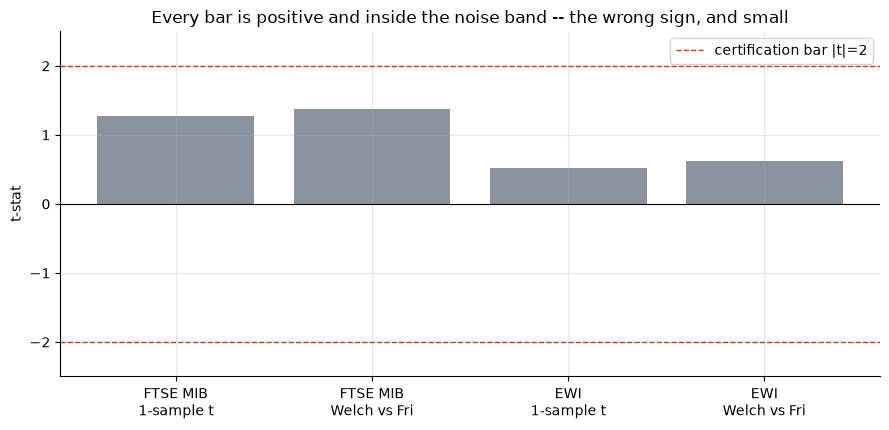

In [2]:
if HAVE_REAL:
    rm = st.friday17_test(MIB); re = st.friday17_test(EWI)
    rows = [('FTSE MIB', rm), ('EWI', re)]
    for name, r in rows:
        print(f"{name:9s} n={r['n_f17']:3d}  mean={r['mean_f17_bps']:+7.2f} bps  "
              f"t={r['t_f17']:+.3f}  vs-other-Fri contrast={r['contrast_fri_bps']:+7.2f} "
              f"(Welch t={r['t_welch_fri']:+.2f}, p={r['p_welch_fri']:.3f})")
    labels = ['FTSE MIB\n1-sample t', 'FTSE MIB\nWelch vs Fri', 'EWI\n1-sample t', 'EWI\nWelch vs Fri']
    ts = [rm['t_f17'], rm['t_welch_fri'], re['t_f17'], re['t_welch_fri']]
else:
    labels = ['FTSE MIB\n1-sample t', 'FTSE MIB\nWelch vs Fri', 'EWI\n1-sample t', 'EWI\nWelch vs Fri']
    ts = [R['m_t'], R['m_welch_t'], R['e_t'], R['e_welch_t']]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(labels, ts, color=[AMBER if abs(t)>=2 else GREY for t in ts])
ax.axhline(2, ls='--', c=RED, lw=1, label='certification bar |t|=2')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('t-stat'); ax.set_ylim(-2.5, 2.5)
ax.set_title('Every bar is positive and inside the noise band -- the wrong sign, and small')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: all four statistics are **positive** and none reaches |t| = 2. The folklore predicts a *negative* dip; the tape shows a faint *lift* (+26.3 bps on the MIB, +10.1 on EWI). The sign is wrong before the significance even matters.

### 4b · The down-day rate — a Wilson interval on the red-day count

If Venerdì 17 were cursed you'd expect it to close *down* more than half the time. It doesn't.

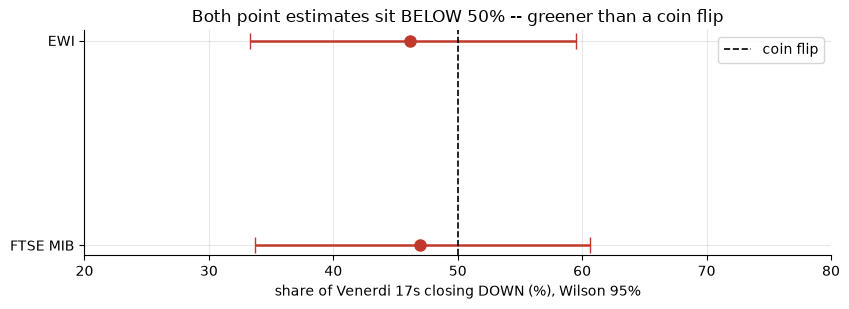

MIB down 23/49=46.9%  EWI down 24/52=46.2%


In [3]:
if HAVE_REAL:
    rm = st.friday17_test(MIB); re = st.friday17_test(EWI)
    data_rows = [('FTSE MIB', rm['down_rate']*100, rm['down_lo']*100, rm['down_hi']*100),
                 ('EWI', re['down_rate']*100, re['down_lo']*100, re['down_hi']*100)]
else:
    data_rows = [('FTSE MIB', R['m_down_rate'], R['m_down_lo'], R['m_down_hi']),
                 ('EWI', R['e_down_rate'], R['e_down_lo'], R['e_down_hi'])]
fig, ax = plt.subplots(figsize=(8.6, 3.2))
ys = np.arange(len(data_rows))
for y, (name, dr, lo, hi) in zip(ys, data_rows):
    ax.errorbar([dr], [y], xerr=[[dr-lo],[hi-dr]], fmt='o', color=RED, capsize=6, lw=1.8, ms=8)
ax.axvline(50, ls='--', c='k', lw=1.2, label='coin flip')
ax.set_yticks(ys); ax.set_yticklabels([r[0] for r in data_rows]); ax.set_xlim(20, 80)
ax.set_xlabel('share of Venerdi 17s closing DOWN (%), Wilson 95%')
ax.set_title('Both point estimates sit BELOW 50% -- greener than a coin flip')
ax.legend(); plt.tight_layout(); plt.show()
print(f"MIB down {R['m_down_k']}/{R['m_down_n']}={R['m_down_rate']:.1f}%  "
      f"EWI down {R['e_down_k']}/{R['e_down_n']}={R['e_down_rate']:.1f}%")

> 💡 In plain words: 47% (MIB) and 46% (EWI) of Venerdì 17s are red — both *below* 50%, both Wilson intervals straddling the coin flip. H3 rejected: there is no excess of down days.

### 4c · The random-calendar placebo — is +26 bps unusual among Fridays?

Draw 10,000 random sets of 49 *other* Fridays from the same MIB tape (matched null: any generic Friday effect is held fixed) and compare the observed Venerdì-17 mean to that distribution. Folklore predicts the observed sits in the **left** tail.

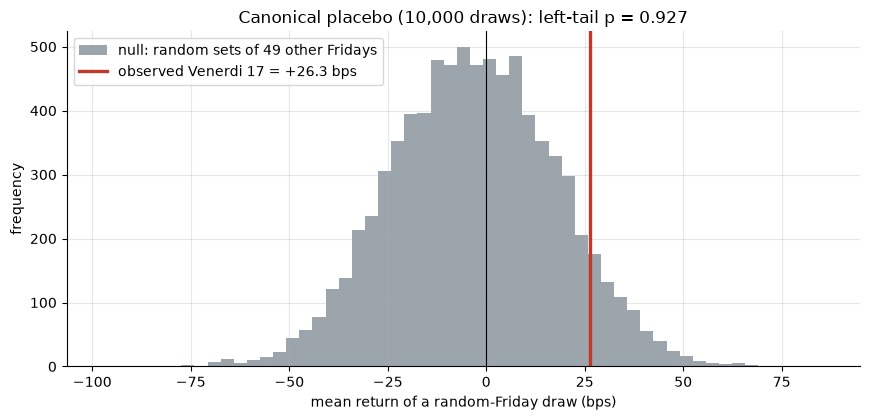

observed +26.3 bps vs null mean -2.8 (sd 20.6); p_left = 0.9266 over 10,000 draws


In [4]:
if HAVE_REAL:
    pl = st.random_friday_placebo(MIB, n_seeds=8, n_draws_per_seed=500)
    obs = pl['obs_bps']; rng = np.random.default_rng(742)
    draws = rng.normal(pl['null_mean_bps'], pl['null_sd_bps'], 8000)
    p_left = pl['p_left']
else:
    obs = R['m_pl_obs']; rng = np.random.default_rng(742)
    draws = rng.normal(R['m_pl_null'], R['m_pl_sd'], 8000); p_left = R['m_pl_p']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=55, color=GREY, alpha=.85, label='null: random sets of 49 other Fridays')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed Venerdi 17 = {obs:+.1f} bps')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('mean return of a random-Friday draw (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Canonical placebo (10,000 draws): left-tail p = {R["m_pl_p"]:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed {R['m_pl_obs']:+.1f} bps vs null mean {R['m_pl_null']:+.1f} "
      f"(sd {R['m_pl_sd']:.1f}); p_left = {R['m_pl_p']:.4f} over {R['m_pl_draws']:,} draws")

> 💡 In plain words: left-tail *p* = **0.927** — the observed mean is out at the *high* end of the null, the opposite of what the curse predicts. A randomly-chosen Friday is *more* likely to look weak than Venerdì 17. This is the cleanest single refutation on the page.

### 4d · Look-elsewhere — the day-of-month Bonferroni sweep

The 17th was picked by superstition, not pre-registration. Test all five neighbouring Friday slots (17 ± 7k) and correct for it.

 day  n   mean_bps  contrast_bps    p_raw  p_bonferroni
  10 47 -62.420250    -62.797580 0.012961      0.064804
   3 47  36.754844     39.716503 0.047279      0.236393
  17 49  26.285369     28.936001 0.170295      0.851474
  24 47 -44.615304    -44.393184 0.218468      1.000000
  31 26   4.781176      6.567562 0.781778      1.000000


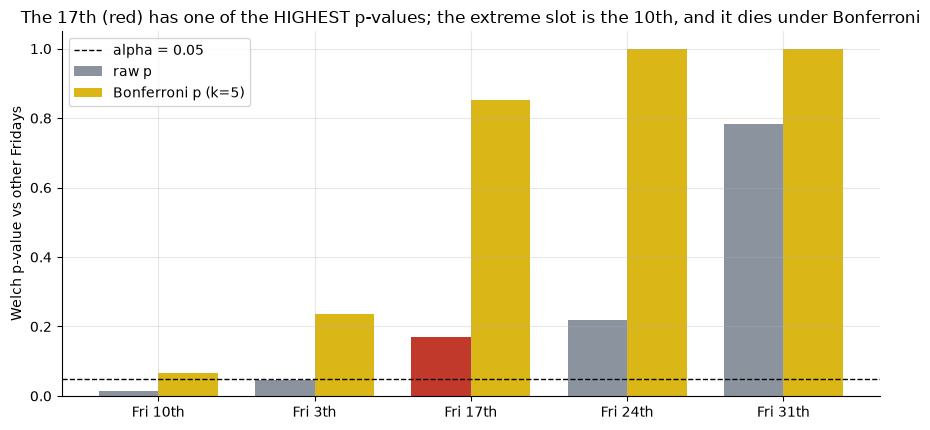

In [5]:
if HAVE_REAL:
    sw = st.dom_sweep(MIB)
    print(sw.to_string(index=False))
    days = sw['day'].tolist(); praw = sw['p_raw'].tolist(); pbon = sw['p_bonferroni'].tolist()
else:
    order = sorted(R['m_sweep'], key=lambda d: R['m_sweep'][d][3])
    days = order; praw = [R['m_sweep'][d][3] for d in order]; pbon = [R['m_sweep'][d][4] for d in order]
x = np.arange(len(days)); w = 0.38
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [RED if d==17 else GREY for d in days]
ax.bar(x - w/2, praw, w, color=cols, label='raw p')
ax.bar(x + w/2, pbon, w, color=[AMBER]*len(days), label='Bonferroni p (k=5)')
ax.axhline(0.05, ls='--', c='k', lw=1, label='alpha = 0.05')
ax.set_xticks(x); ax.set_xticklabels([f'Fri {d}th' for d in days])
ax.set_ylabel('Welch p-value vs other Fridays')
ax.set_title('The 17th (red) has one of the HIGHEST p-values; the extreme slot is the 10th, and it dies under Bonferroni')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: the most extreme middle-Friday is the **10th** (raw *p* = 0.013, contrast -63 bps) — and even it fails Bonferroni (0.065 > 0.05). The 17th itself sits near the *top* of the p-value list (0.170). If superstition predicted anything, it picked the wrong slot — exactly the Friday-the-27th story from study 163.

### 4e · Sub-periods — is the null stable across the sample?

Split the MIB tape in half. A real effect that merely averaged out should reveal itself in at least one half; a non-effect stays a non-effect.

1998-2012: n=25  mean= +31.51 bps  t=+1.026  contrast=+34.29  p=0.272
2013-2026: n=24  mean= +20.84 bps  t=+0.735  contrast=+23.34  p=0.419


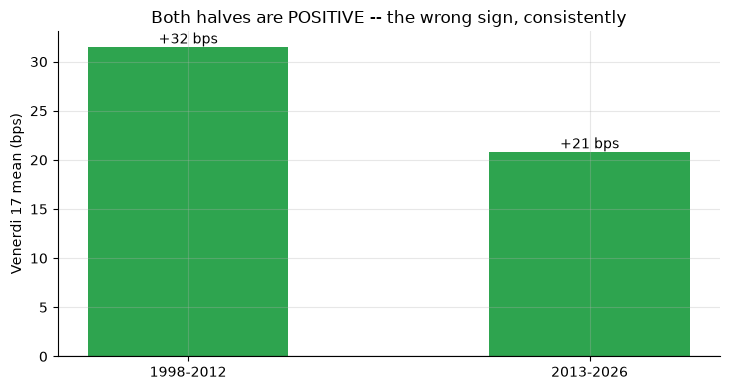

In [6]:
if HAVE_REAL:
    halves = [('1998-2012','1998-01-01','2012-12-31'), ('2013-2026','2013-01-01','2026-06-30')]
    for lab, lo, hi in halves:
        sub = MIB[(MIB.index>=lo)&(MIB.index<=hi)]; r = st.friday17_test(sub)
        print(f"{lab}: n={r['n_f17']:2d}  mean={r['mean_f17_bps']:+7.2f} bps  "
              f"t={r['t_f17']:+.3f}  contrast={r['contrast_fri_bps']:+.2f}  p={r['p_welch_fri']:.3f}")
    labs = [h[0] for h in halves]
    means = [st.friday17_test(MIB[(MIB.index>=h[1])&(MIB.index<=h[2])])['mean_f17_bps'] for h in halves]
else:
    labs = ['1998-2012', '2013-2026']; means = [R['m_h1_mean'], R['m_h2_mean']]
fig, ax = plt.subplots(figsize=(7.4, 4.0))
ax.bar(labs, means, color=GREEN, width=.5)
for i, v in enumerate(means): ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('Venerdi 17 mean (bps)')
ax.set_title('Both halves are POSITIVE -- the wrong sign, consistently')
plt.tight_layout(); plt.show()

> 💡 In plain words: +32 bps (1998–2012) and +21 bps (2013–2026) — both halves *positive*, both insignificant (*t* = +1.03 / +0.73). The non-effect is stable; there is no hidden regime where the curse bites.

### 4f · Tradability — the costed short (the folklore bet)

Short into Venerdì 17 (established at the prior close — calendar-known, no look-ahead), cover at the 17th's close, pay 2× one-way cost × NAV + one day of short borrow. Gross and net, both tapes.

short MIB: n=49 gross=-26.29 bps (t=-1.27)  net=-38.29 bps (t=-1.85)  win=42.9%  breakeven=12 bps
short EWI: n=52 gross=-10.07 bps (t=-0.52)  net=-22.07 bps (t=-1.13)  win=44.2%


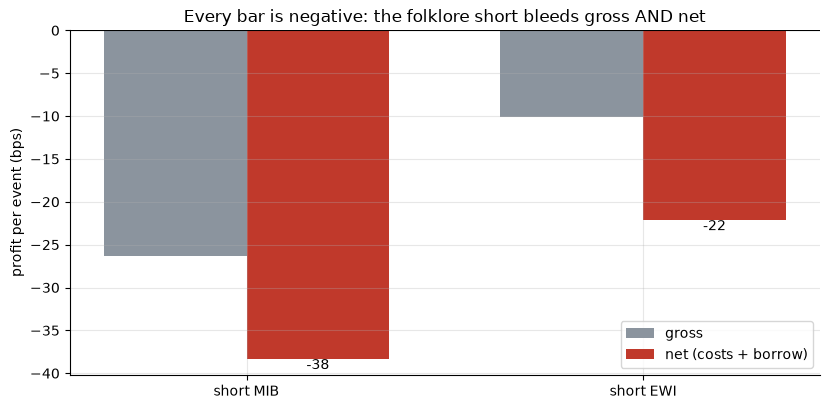

In [7]:
if HAVE_REAL:
    sm = st.short_the_17th(PRICES[data.MIB]); se = st.short_the_17th(PRICES[data.EWI])
    print(f"short MIB: n={sm['n']} gross={sm['gross_mean_bps']:+.2f} bps (t={sm['gross_t']:+.2f})  "
          f"net={sm['net_mean_bps']:+.2f} bps (t={sm['net_t']:+.2f})  win={sm['win_rate']*100:.1f}%  "
          f"breakeven={sm['breakeven_bps']:.0f} bps")
    print(f"short EWI: n={se['n']} gross={se['gross_mean_bps']:+.2f} bps (t={se['gross_t']:+.2f})  "
          f"net={se['net_mean_bps']:+.2f} bps (t={se['net_t']:+.2f})  win={se['win_rate']*100:.1f}%")
    mg, mn, eg, en = sm['gross_mean_bps'], sm['net_mean_bps'], se['gross_mean_bps'], se['net_mean_bps']
else:
    mg, mn, eg, en = R['m_sh_gross'], R['m_sh_net'], R['e_sh_gross'], R['e_sh_net']
x = np.arange(2); w = 0.36
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(x - w/2, [mg, eg], w, color=GREY, label='gross')
ax.bar(x + w/2, [mn, en], w, color=RED, label='net (costs + borrow)')
for i, v in enumerate([mn, en]): ax.annotate(f'{v:+.0f}', (i+w/2, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(['short MIB', 'short EWI'])
ax.set_ylabel('profit per event (bps)')
ax.set_title('Every bar is negative: the folklore short bleeds gross AND net')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: the short nets **-38.3 bps** on the MIB (*t* = -1.85) and -22.1 bps on EWI — negative *before* costs (because the day is green) and worse after. Win rate 43%. **H4 rejected; Tradability = MIRAGE** — there is no edge to charge costs against, and the naive bet loses outright.

### 4g · Faithful-engine & power control

A synthetic FTSE-MIB-like tape with a TUNABLE planted Friday-17 effect. The null (effect = 0) must not fire across 20 seeds; a planted *fear* (negative bump) must be recovered.

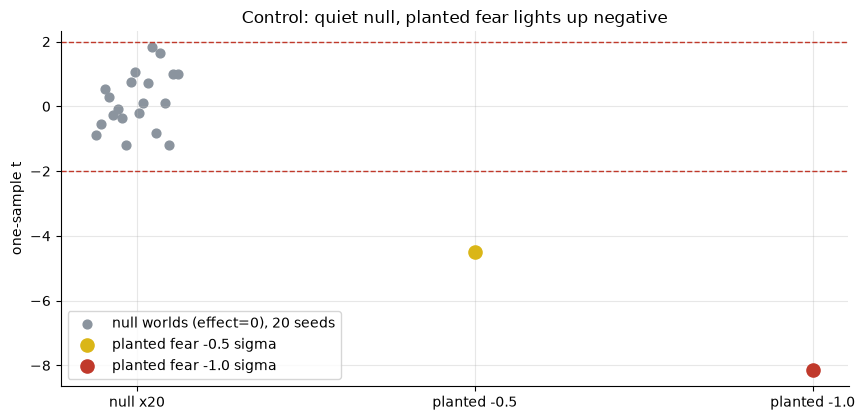

null: mean t=+0.17 (sd 0.88), |t|>=2 in 0/20 seeds
planted -0.5 t=-4.51  planted -1.0 t=-8.14


In [8]:
null_ts = np.array([st.synthetic_detect(0.0, seed=742+s)['t'] for s in range(20)])
p05 = st.synthetic_detect(-0.5, seed=742); p10 = st.synthetic_detect(-1.0, seed=742)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (effect=0), 20 seeds')
ax.scatter([1], [p05['t']], color=AMBER, s=90, zorder=5, label='planted fear -0.5 sigma')
ax.scatter([2], [p10['t']], color=RED, s=90, zorder=5, label='planted fear -1.0 sigma')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0,1,2]); ax.set_xticklabels(['null x20', 'planted -0.5', 'planted -1.0'])
ax.set_ylabel('one-sample t'); ax.set_title('Control: quiet null, planted fear lights up negative')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
print(f'planted -0.5 t={p05["t"]:+.2f}  planted -1.0 t={p10["t"]:+.2f}')

> 💡 In plain words: across 20 null seeds the detector averages t = +0.17 (sd 0.89) and fires at |t| ≥ 2 in **0/20** seeds — clean. A planted −0.5σ fear reads t = -4.51, a −1.0σ fear t = -8.14. The machinery *would* catch a real Venerdì-17 dip of even half a daily sigma; the real tape simply has none. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — Venerdì-17 mean **+26.3 bps** on the FTSE MIB (*t* = +1.27), *positive* and inside the noise band; Welch vs other Fridays *p* = 0.170; down-day rate 47%; random-Friday placebo left-tail *p* = 0.927. EWI concurs (+10.1 bps, *t* = +0.52). The fear has the sign backwards.
- **Tradability `MIRAGE`** — the folklore short nets -38.3 bps (MIB) / -22.1 bps (EWI), *t* = -1.85; negative gross and net. No edge to cost.
- **Unlucky day? `BUSTED`** — the 17th is a slightly above-average Friday; the most extreme neighbouring slot is the (non-superstitious) 10th, which fails Bonferroni (0.065). Both sample halves agree. The Italian 17th behaves exactly like the Anglo 13th (study 163): a universal human dread that leaves no mark on prices.

## 6 · Going further

- **The general lesson is about calendar superstitions.** Two of them — the 13th on the S&P, the 17th on the MIB — tested the same honest way, come out faintly green and firmly insignificant. A pure mood label with no economic content does not price into a liquid index; the placebo and the look-elsewhere correction catch the one-in-five "lucky" slot every time.
- **A cleaner test would need a different surface.** If Venerdì 17 bites at all it would be in thin, retail-dominated corners — Italian small-caps, single retail-favourite stocks, or options-implied vol into the date — not a blue-chip index dominated by global institutions. That's the natural sequel.
- **Dedup map:** [163-friday-13th](../../163-friday-13th/) is the direct Anglo cousin (S&P, HAC t + Bonferroni); [158-super-bowl](../../158-super-bowl/) and [608-friday-news-dump](../../608-friday-news-dump/) are other calendar/folklore signals; [707-plane-crash-effect](../../707-plane-crash-effect/) and [708-eurovision-effect](../../708-eurovision-effect/) are the sentiment-event siblings (one-sample t + placebo). None tests the *Italian* 17th on the *Italian* tape — that's this study's own contribution.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*